## 报告

### 代码

github地址：[https://github.com/foxabbage/cv-hw](https://github.com/foxabbage/cv-hw)下目录hw1，模型较小，也保存在目录下，具体位置详见hw1/README.md

### 模型结构

这个3层MLP模型由2个可以自定义大小的全连接隐藏层和一个输出层构成，输入一个784维向量，输出一个10维向量，代表10个不同类别的概率，取最大的类别标签作为该图像的预测。<br>
非线性激活函数可以选择relu或sigmoid，损失函数使用交叉熵损失函数。<br>

### 数据预处理

通过gzip读取fashion_mnist数据集，分别存储图像矩阵和标签，将图像矩阵按行展平，并对每个数从[0, 255]上归一化到[0, 1]，取80%作为训练集，20%作为验证集。<br>

### 实验

通过网格搜索分别得到relu和sigmoid作为激活函数的最佳超参数并保存模型。<br>
第一次参数：learning_rate=[1e-5, 1e-4, 1e-3], weight_decay=[1e-5, 1e-4], hidden_layer = [[128, 32], [128, 64], [256, 64]], activation = relu<br>
第二次参数：learning_rate=[5e-4], weight_decay=[1e-4, 1e-3], hidden_layer = [[128, 32], [128, 64], [256, 64]], activation = relu<br>
第三次参数：learning_rate=[1e-3, 5r-3], weight_decay=[1e-4, 1e-3], hidden_layer = [[128, 32]], activation = sigmoid<br>
第一次搜索训练图：<br>

<table>
  <tr>
    <td><img src="grid_search_results/run_0_lr1e-05_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_1_lr1e-05_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_2_lr1e-05_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_3_lr1e-05_wd0.0001.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_4_lr1e-05_wd0.0001.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_5_lr1e-05_wd0.0001.png" alt="grid1"></td>
  </tr>
  <tr>
    <td><img src="grid_search_results/run_6_lr0.0001_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_7_lr0.0001_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_8_lr0.0001_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_9_lr0.0001_wd0.0001.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_10_lr0.0001_wd0.0001.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_11_lr0.0001_wd0.0001.png" alt="grid1"></td>
  </tr>
  <tr>
    <td><img src="grid_search_results/run_12_lr0.001_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_13_lr0.001_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_14_lr0.001_wd1e-05.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_15_lr0.001_wd0.0001.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_16_lr0.001_wd0.0001.png" alt="grid1"></td>
    <td><img src="grid_search_results/run_17_lr0.001_wd0.0001.png" alt="grid1"></td>
  </tr>
</table>

<br>第二次搜索训练图：<br>

<table>
  <tr>
    <td><img src="grid_search_results_2/run_0_lr0.0005_wd0.0001.png" alt="grid2"></td>
    <td><img src="grid_search_results_2/run_1_lr0.0005_wd0.0001.png" alt="grid2"></td>
    <td><img src="grid_search_results_2/run_2_lr0.0005_wd0.0001.png" alt="grid2"></td>
  </tr>
  <tr>
    <td><img src="grid_search_results_2/run_3_lr0.0005_wd0.001.png" alt="grid2"></td>
    <td><img src="grid_search_results_2/run_4_lr0.0005_wd0.001.png" alt="grid2"></td>
    <td><img src="grid_search_results_2/run_5_lr0.0005_wd0.001.png" alt="grid2"></td>
  </tr>
</table>

<br>第三次搜索训练图：<br>

<table>
  <tr>
    <td><img src="grid_search_results_3/run_0_lr0.001_wd0.0001.png" alt="grid3"></td>
    <td><img src="grid_search_results_3/run_1_lr0.001_wd0.001.png" alt="grid3"></td>
  </tr>
  <tr>
    <td><img src="grid_search_results_3/run_2_lr0.005_wd0.0001.png" alt="grid3"></td>
    <td><img src="grid_search_results_3/run_3_lr0.005_wd0.001.png" alt="grid3"></td>
  </tr>
</table>

<br>由于第一次实验中看到学习率对模型训练影响较大，1e-4得到的模型准确率较低，1e-3的训练过程波动较大，因此选取5e-4做第二组实验<br>
三次最好的超参数分别为：[lr, wd, hl] = [1e-3, 1e-5, [256, 64]]/[5e-4, 1e-4, [256, 64]]/[5e-3, 1e-4, [128, 32]]<br>

### 测试


In [1]:
from read_dataset import read_mnist_images, read_mnist_labels
from model import MLP
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

test_images = read_mnist_images('fashion/t10k-images-idx3-ubyte.gz')
test_images = test_images.reshape(test_images.shape[0], -1).astype(np.float32) / 255.0
test_labels = read_mnist_labels('fashion/t10k-labels-idx1-ubyte.gz')
test_labels = test_labels.astype(np.int32)

model1 = MLP([784,256,64,10], local_para_path="grid_search_results/best_model.npz")
model2 = MLP([784,256,64,10], local_para_path="grid_search_results_2/best_model.npz")
model3 = MLP([784,128,32,10], local_para_path="grid_search_results_3/best_model.npz", activation_function="sigmoid")

pred1, loss1 = model1.infer(test_images, test_labels)
pred2, loss2 = model2.infer(test_images, test_labels)
pred3, loss3 = model3.infer(test_images, test_labels)

def print_evaluation(model_name, pred, true_labels, loss):
    print(f"[{model_name}]")
    acc = accuracy_score(true_labels, pred)
    print(f"1. Accuracy: {acc:.4f}")
    avg_loss = np.mean(loss) if hasattr(loss, '__len__') else loss
    print(f"2. Loss: {avg_loss:.4f}")
    cm = confusion_matrix(true_labels, pred)
    print("3. Confusion Matrix:")
    print(cm)
    error_idx = np.where(pred != true_labels)[0]
    if len(error_idx) > 0:
        n = min(10, len(error_idx))
        sample_idx = np.random.choice(error_idx, size=n, replace=False)
        sample_idx.sort()
        print(f"4. random 10 errors: {sample_idx}")
        print(f"pred: {pred[sample_idx]}")
        print(f"true: {true_labels[sample_idx]}")
    else:
        print("4. no error")
        
    print("=" * 45)

print_evaluation("Model 1 (best_model.npz)", pred1, test_labels, loss1)
print_evaluation("Model 2 (best_model.npz)", pred2, test_labels, loss2)
print_evaluation("Model 3 (best_model.npz)", pred3, test_labels, loss3)

Magic: 2051, Images: 10000, Size: 28x28
Magic: 2049, Labels: 10000
[Model 1 (best_model.npz)]
1. Accuracy: 0.8872
2. Loss: 0.3232
3. Confusion Matrix:
[[846   1  16  21   5   2 101   0   8   0]
 [  1 971   0  21   2   0   4   0   1   0]
 [ 13   0 795  19  94   1  75   0   3   0]
 [ 24   9  12 896  29   1  23   0   6   0]
 [  1   1  84  31 831   0  48   0   4   0]
 [  0   0   0   1   0 963   0  25   1  10]
 [110   1  84  30  67   0 699   0   9   0]
 [  0   0   0   0   0  19   0 957   0  24]
 [  5   0   3   9   6   5   9   4 959   0]
 [  0   0   0   0   0   8   1  36   0 955]]
4. random 10 errors: [ 800 2373 4608 5161 5397 5919 8536 8659 9114 9398]
pred: [9 2 6 4 2 2 2 3 6 6]
true: [7 6 4 6 4 4 4 2 0 0]
[Model 2 (best_model.npz)]
1. Accuracy: 0.8764
2. Loss: 0.3468
3. Confusion Matrix:
[[829   1  18  34   5   1 104   0   8   0]
 [  2 969   0  21   2   0   4   0   2   0]
 [ 18   1 802  17  89   1  70   0   2   0]
 [ 25   8  11 894  30   0  26   0   6   0]
 [  0   1 101  32 799   0  63   0

可以看到三个模型在测试集上表现接近，都在88%附近，并且都容易将类6与类0混淆，容易将类4与类2混淆。<br>

### 特征可视化

第一个网格搜索得到的权重矩阵可视化：<br>
![p1](./h1.png)
<br>第三个网格搜索得到的权重矩阵可视化：<br>
![p3](./h3.png)
<br>可以看到第一张图较为模糊，可以看到部分衣物的比如衬衫的轮廓，但是噪声较重，可能是损失已经收敛，但权重矩阵仍为收敛。第二张图则可以较为清晰的看到上衣模板，由于占比大，因此轮廓更为清晰。部分图中可以模糊的看出鞋子，裙子的轮廓与上衣重叠在一起。

### 错误可视化


Magic: 2051, Images: 10000, Size: 28x28


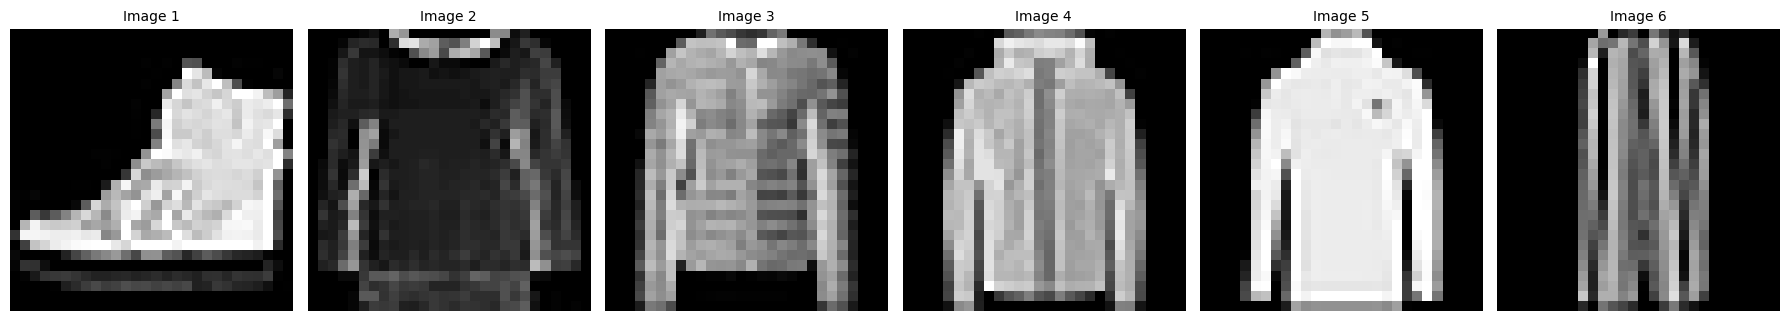

In [2]:
from read_dataset import read_mnist_images
import matplotlib.pyplot as plt
import numpy as np

def visualize_gray_images(images, figsize=(18, 4)):
    n = len(images)
    titles = [f'Image {i+1}' for i in range(n)]
    fig, axes = plt.subplots(1, n, figsize=figsize)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

test_images = read_mnist_images('fashion/t10k-images-idx3-ubyte.gz')
li = []
for i in [800,2373,5397,5919,7299,9095]:
    li.append(test_images[i])
visualize_gray_images(li)

可以看到分类将鞋子类混淆，上衣类混淆以及裤子/裙子混淆，从外观上看确实有相似之处，从人类的角度看，在图片不清晰的情况下确实也容易看错。